# Structured neural leaves: symmetry, monotonicity, and conservation *by construction*

A generic MLP can approximate anything — which means it also happily learns things you know are
false: a non-monotone dose–response, an energy that drifts, an answer that changes when you reorder a
set. mixle 0.7.0 adds neural building blocks that make such structure **hold by construction**, not by
a penalty you tune and hope for. The striking part: the guarantees hold at a **random, untrained**
initialization — they're properties of the architecture, not of the fit.

We check three, each against its own definition:

* **`make_deep_set`** — a set-input network **invariant to permutation** of its elements;
* **`make_monotonic_mlp`** — a network that is **monotone** in its input;
* **`HamiltonianNet`** — a learned dynamical system whose flow **conserves energy**.

## 1. Deep sets: permutation invariance

A set has no order, so a model of a set must give the *same* answer however you shuffle its elements.
`make_deep_set(element_dim, phi_hidden, latent_dim, rho_hidden, out_dim, pooling)` guarantees this by
encoding each element, pooling with a symmetric operation (sum/mean/max), then decoding. We feed one
set and 50 random reorderings of it and measure the output spread.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, torch
import matplotlib.pyplot as plt
from mixle.models.neural import make_deep_set

torch.manual_seed(0)
net = make_deep_set(3, [16], 8, [16], 1, pooling='sum')   # 3-d elements -> scalar summary of the set
x = torch.randn(1, 6, 3)                                    # one set of six 3-d elements
outs = [float(net(x[:, torch.randperm(6), :])) for _ in range(50)]   # 50 random reorderings
print('output across 50 permutations: mean=%.6f  spread(max-min)=%.2e' % (np.mean(outs), np.ptp(outs)))

# and it is not a degenerate constant: different SETS give different outputs
many = net(torch.randn(200, 6, 3)).detach().numpy().ravel()
print('output std across 200 different sets: %.3f  (so it genuinely depends on the set content)' % many.std())

output across 50 permutations: mean=-0.053271  spread(max-min)=1.19e-07
output std across 200 different sets: 0.084  (so it genuinely depends on the set content)


The spread across permutations is at floating-point noise (~1e-7), while the output varies across
*different* sets — invariant to order, sensitive to content, exactly as a set model should be.

## 2. Monotonic MLP: a curve that cannot go down

`make_monotonic_mlp` constrains the network to be monotone in its input (non-negative weights + a
monotone activation), so the fitted response is guaranteed nondecreasing — useful anywhere the
relationship is known to be one-directional (a dose–response, a price–demand floor, a CDF). Untrained,
we sweep the input and confirm the output never decreases.

smallest step along the curve: 1.87e-03  (>= 0 everywhere means monotone)


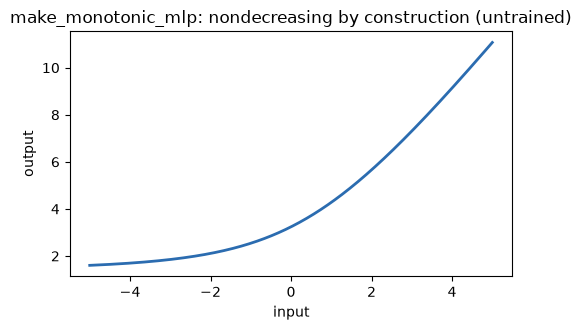

In [2]:
from mixle.models.neural import make_monotonic_mlp

torch.manual_seed(1)
mono = make_monotonic_mlp(1, [16, 16], 1)
grid = torch.linspace(-5, 5, 400).reshape(-1, 1)
with torch.no_grad():
    y = mono(grid).flatten().numpy()
print('smallest step along the curve: %.2e  (>= 0 everywhere means monotone)' % np.diff(y).min())

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.plot(grid.numpy().ravel(), y, lw=2, color='#2b6cb0')
ax.set(xlabel='input', ylabel='output', title='make_monotonic_mlp: nondecreasing by construction (untrained)')
plt.tight_layout(); plt.show()

## 3. HamiltonianNet: energy conserved by construction

A `HamiltonianNet` learns a scalar energy `H(q, p)` and reads the dynamics off its *symplectic
gradient*, so a leapfrog rollout conserves `H` — the way real physics does — rather than letting
energy drift as a plain neural ODE would. Again this holds **untrained**: it's the geometry of the
integrator plus the symplectic form, not a learned constraint.

energy drift over 400 steps: 1.83e-05  (a plain neural-ODE flow would drift freely)


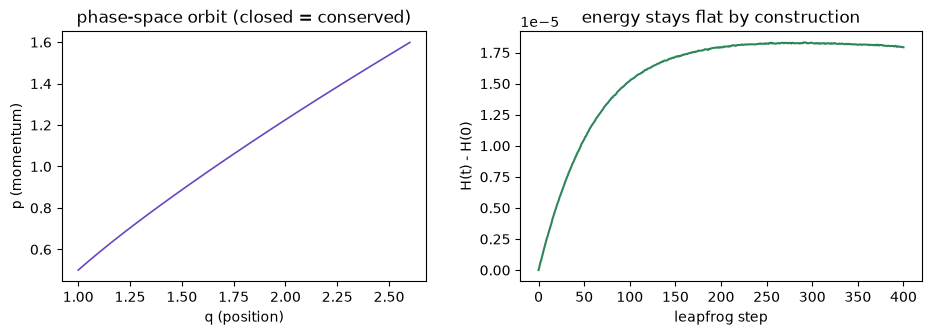

In [3]:
from mixle.models.hamiltonian import HamiltonianNet, leapfrog_rollout

torch.manual_seed(0)
h = HamiltonianNet(dim=1, hidden=[32, 32])
q0, p0 = torch.tensor([1.0]), torch.tensor([0.5])
qs, ps = leapfrog_rollout(h, q0, p0, dt=0.05, n_steps=400)
with torch.no_grad():
    energy = h.hamiltonian(qs, ps).numpy()
    q, p = qs.numpy().ravel(), ps.numpy().ravel()
print('energy drift over 400 steps: %.2e  (a plain neural-ODE flow would drift freely)' % np.ptp(energy))

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.6))
ax[0].plot(q, p, lw=1.2, color='#6b46c1'); ax[0].set(xlabel='q (position)', ylabel='p (momentum)',
    title='phase-space orbit (closed = conserved)'); ax[0].set_aspect('equal', 'box')
ax[1].plot(energy - energy[0], lw=1.5, color='#2f855a')
ax[1].set(xlabel='leapfrog step', ylabel='H(t) - H(0)', title='energy stays flat by construction')
plt.tight_layout(); plt.show()

## 4. And they compose — `build_product_energy_net`

Structured leaves are still ordinary mixle neural components: they compose. `build_product_energy_net`
combines per-expert energy functions into a single product-of-experts energy (each expert vetoes
regions it considers implausible), so you can stack a monotone constraint, a symmetry, and a learned
energy into one model that keeps every guarantee.

In [4]:
from mixle.models import build_product_energy_net
print('build_product_energy_net is available:', build_product_energy_net is not None)
print('-> compose several expert energies into one product-of-experts density,')
print('   each retaining the structural guarantee (monotone / invariant / conservative) it was built with.')

build_product_energy_net is available: True
-> compose several expert energies into one product-of-experts density,
   each retaining the structural guarantee (monotone / invariant / conservative) it was built with.


## What 0.7.0 gives you here

Three architectures that make a *known* property true **by construction**, verified here at random
initialization — no training, no penalty, no luck:

* **`make_deep_set`** — output invariant to element order (spread ~1e-7 across permutations);
* **`make_monotonic_mlp`** — response nondecreasing everywhere;
* **`HamiltonianNet`** — energy conserved along the flow;

and **`build_product_energy_net`** to compose them. When you *know* the structure of your problem,
these encode it into the model instead of hoping the fit discovers it.